# Workshop 3 — Notebook 2: Gold Layer Preview
**Course:** Data Analysis Programming 2026-I  
**Topic:** Real Madrid Public Opinion & Sentiment Analysis  
**Purpose:** Read and preview all Gold Parquet files produced by the Gold DAG — governance summary and all storytelling aggregations. This notebook demonstrates that the Gold layer is correctly produced and ready for the Workshop 4 dashboards.

## 1. Setup

In [21]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

GOLD_PATH = r"C:\Users\Esteban\Documents\Data_analysis\Project\datalake_gold"

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

print('Libraries loaded.')

Libraries loaded.


## 2. Helper — Load Latest Parquet by Pattern

In [22]:
def load_latest(pattern, label):
    """Load the most recent Gold Parquet matching the pattern."""
    files = sorted(glob.glob(os.path.join(GOLD_PATH, pattern)))
    if not files:
        print(f'[{label}] No files found matching: {pattern}')
        return pd.DataFrame()
    latest = files[-1]
    df = pd.read_parquet(latest)
    print(f'[{label}] Loaded: {os.path.basename(latest)} — {len(df)} rows × {len(df.columns)} cols')
    return df

print('Helper loaded.')

Helper loaded.


## 3. Gold Files Inventory

In [23]:
all_gold_files = sorted([
    f for f in os.listdir(GOLD_PATH)
    if f.endswith('.parquet')
])

print(f'Gold Parquet files found: {len(all_gold_files)}')
for f in all_gold_files:
    full = os.path.join(GOLD_PATH, f)
    size_kb = os.path.getsize(full) / 1024
    print(f'  {f:65s} {size_kb:8.1f} KB')

Gold Parquet files found: 20
  aspect_sentiment_20260529_214358.parquet                               7.1 KB
  aspect_sentiment_20260529_215406.parquet                               7.4 KB
  gold_realmadrid_20260529_214354.parquet                              217.2 KB
  gold_realmadrid_20260529_215404.parquet                              738.6 KB
  governance_20260529_214354.parquet                                    35.1 KB
  governance_20260529_215404.parquet                                    35.1 KB
  keyword_sentiment_20260529_214358.parquet                              3.5 KB
  keyword_sentiment_20260529_215406.parquet                              3.6 KB
  sentiment_distribution_20260529_214358.parquet                         3.1 KB
  sentiment_distribution_20260529_215406.parquet                         3.1 KB
  sentiment_trend_20260529_214358.parquet                                3.2 KB
  sentiment_trend_20260529_215406.parquet                                3.2 KB
  source_co

## 4. Gold Base — Full Enriched Dataset

In [24]:
df_gold = load_latest('gold_realmadrid_*.parquet', 'GOLD BASE')

if not df_gold.empty:
    print('\n--- Schema ---')
    print(df_gold.dtypes)
    print('\n--- Sample (5 rows) ---')
    display(df_gold.head(50))

[GOLD BASE] Loaded: gold_realmadrid_20260529_215404.parquet — 280 rows × 22 cols

--- Schema ---
url                             str
title                           str
author                          str
published_at         datetime64[us]
body_text                       str
body_text_clean                 str
title_clean                     str
body_text_missing              bool
source                          str
bronze_source                   str
score                       float64
num_comments                float64
subreddit                       str
reading_time_min            float64
text_processed                  str
title_processed                 str
token_count                   int64
vader_compound              float64
vader_pos                   float64
vader_neg                   float64
vader_neu                   float64
sentiment_label                 str
dtype: object

--- Sample (5 rows) ---


,url,title,author,published_at,body_text,body_text_clean,title_clean,body_text_missing,source,bronze_source,...,subreddit,reading_time_min,text_processed,title_processed,token_count,vader_compound,vader_pos,vader_neg,vader_neu,sentiment_label
0,https://www.football-espana.net/2026/05/04/el-...,El Clasico return in doubt for Kylian Mbappe,John Menzies,2026-05-04 09:01:30,Real Madrid kept alive their slim La Liga titl...,real madrid kept alive their slim la liga titl...,el clasico return in doubt for kylian mbappe,False,scraping,web_scraping_realmadrid_20260529_215223.json,...,NaN,2.0,keep alive slim la liga title hope victory esp...,el clasico return doubt kylian mbappe,122,-0.9657,0.081,0.167,0.752,negative
1,https://www.football-espana.net/2026/05/04/for...,Forward has reservations about Real Madrid return,John Menzies,2026-05-04 10:23:34,Real Madrid have had a very difficult second h...,real madrid have had a very difficult second h...,forward has reservations about real madrid return,False,scraping,web_scraping_realmadrid_20260529_215223.json,...,NaN,2.0,difficult second half case endrick felipe loan...,forward reservation return,122,0.9913,0.198,0.029,0.772,positive
2,https://www.football-espana.net/2026/05/04/rea...,VIDEO: Real Madrid defender's reaction to Arbe...,John Menzies,2026-05-04 10:54:02,Real Madrid may havewon 2-0 at Espanyolon Sund...,real madrid may havewon 20 at espanyolon sunda...,video real madrid defenders reaction to arbelo...,False,scraping,web_scraping_realmadrid_20260529_215223.json,...,NaN,2.0,havewon espanyolon sunday result come injury p...,video defender reaction arbeloa snub go viral,142,-0.5927,0.063,0.083,0.854,negative
3,https://www.football-espana.net/2026/05/04/sec...,Second Real Madrid defender to undergo surgery,Ruairidh Barlow,2026-05-04 14:27:00,The injury hell that Ferland Mendy has been go...,the injury hell that ferland mendy has been go...,second real madrid defender to undergo surgery,False,scraping,web_scraping_realmadrid_20260529_215223.json,...,NaN,2.0,injury hell ferland mendy go continue fresh su...,second defender undergo surgery,120,0.6059,0.082,0.056,0.862,positive
4,https://www.football-espana.net/2026/05/05/arb...,Arbeloa's indirect messages to Real Madrid sta...,Ruairidh Barlow,2026-05-05 08:52:10,Kylian Mbappe has attracted the ire of the pre...,kylian mbappe has attracted the ire of the pre...,arbeloas indirect messages to real madrid star...,False,scraping,web_scraping_realmadrid_20260529_215223.json,...,NaN,2.0,kylian mbappe attract ire press spanish capita...,arbeloas indirect message star kylian mbappe,201,0.9110,0.120,0.057,0.823,positive
5,https://www.football-espana.net/2026/05/05/del...,COLUMN: Let's stop deluding ourselves about Re...,Jeremy Beren,2026-05-05 17:00:00,"Jeremy Beren can be found on social mediahere,...",jeremy beren can be found on social mediahere ...,column lets stop deluding ourselves about real...,False,scraping,web_scraping_realmadrid_20260529_215223.json,...,NaN,2.0,jeremy beren find social mediahere hungry find...,column let stop delude españa,165,0.9061,0.093,0.029,0.878,positive
6,https://www.football-espana.net/2026/05/05/mba...,Mbappe camp responds to alleged spat with Real...,Ruairidh Barlow,2026-05-05 14:43:58,Real Madrid forward Kylian Mbappe has called r...,real madrid forward kylian mbappe has called r...,mbappe camp responds to alleged spat with real...,False,scraping,web_scraping_realmadrid_20260529_215223.json,...,NaN,2.0,forward kylian mbappe call report tension memb...,mbappe camp respond allege spat coach,196,-0.8074,0.036,0.084,0.880,negative
7,https://www.football-espana.net/2026/05/05/pre...,Premier League manager 'high' on Real Madrid s...,Ruairidh Barlow,2026-05-05 17:44:34,Real Madrid manager Alvaro Arbeloa is not expe...,real madrid manager alvaro arbeloa is not expe...,premier league manager high on real madrid sho...,False,scraping,web_scraping_realmadrid_20260529_215223.json,...,NaN,2.0,manager alvaro arbeloa expec

In [25]:
df_gold[
    [
        "source",
        "title",
        "vader_compound",
        "sentiment_label"
    ]
].sort_values("vader_compound")

,source,title,vader_compound,sentiment_label
259,reddit,[SF] Preserve civilization,-0.9971,negative
36,scraping,Real Madrid dressing room blame Valverde for T...,-0.9867,negative
21,scraping,Valverde in hospital after second fight with R...,-0.9779,negative
98,scraping,Fede Valverde returns to Real Madrid training ...,-0.9770,negative
25,scraping,"Real Madrid explore bans, sales after fight: l...",-0.9715,negative
...,...,...,...,...
273,reddit,Which soccer team should I support guys💔🥀?,0.9933,positive
131,scraping,3 Real Madrid and Barcelona player join Neymar...,0.9964,positive
251,reddit,How is anything Enrique said connected to fixi...,0.9972,positive
258,reddit,[FIFA 07] World Wide League 07 Week 19 Stats R...,0.9999,positive


In [26]:
df_gold[
    [
        "source",
        "title",
        "vader_compound",
        "sentiment_label"
    ]
].sort_values(
    "vader_compound",
    ascending=False
)

,source,title,vader_compound,sentiment_label
227,reddit,Why Going Trophyless Was The Best Thing That E...,0.9999,positive
258,reddit,[FIFA 07] World Wide League 07 Week 19 Stats R...,0.9999,positive
251,reddit,How is anything Enrique said connected to fixi...,0.9972,positive
131,scraping,3 Real Madrid and Barcelona player join Neymar...,0.9964,positive
273,reddit,Which soccer team should I support guys💔🥀?,0.9933,positive
...,...,...,...,...
25,scraping,"Real Madrid explore bans, sales after fight: l...",-0.9715,negative
98,scraping,Fede Valverde returns to Real Madrid training ...,-0.9770,negative
21,scraping,Valverde in hospital after second fight with R...,-0.9779,negative
36,scraping,Real Madrid dressing room blame Valverde for T...,-0.9867,negative


In [27]:
df_gold[
    df_gold["source"] == "scraping"
][
    [
        "title",
        "vader_compound",
        "sentiment_label"
    ]
]

,title,vader_compound,sentiment_label
0,El Clasico return in doubt for Kylian Mbappe,-0.9657,negative
1,Forward has reservations about Real Madrid return,0.9913,positive
2,VIDEO: Real Madrid defender's reaction to Arbe...,-0.5927,negative
3,Second Real Madrid defender to undergo surgery,0.6059,positive
4,Arbeloa's indirect messages to Real Madrid sta...,0.9110,positive
...,...,...,...
195,Fourth Real Madrid star snubbed from World Cup,0.2960,positive
196,Florentino Perez confirms upcoming Negreira ca...,0.8710,positive
197,Jose Mourinho signs contract to become new Rea...,0.3662,positive
198,Perez lines up 3 transfers if he is re-elected...,0.9601,positive


In [28]:
if not df_gold.empty:
    print('=== GOLD BASE DESCRIPTIVE STATISTICS ===')
    numeric_cols = ['score', 'num_comments', 'reading_time_min',
                    'vader_compound', 'vader_pos', 'vader_neg', 'vader_neu', 'token_count']
    existing = [c for c in numeric_cols if c in df_gold.columns]
    display(df_gold[existing].describe().round(4))

=== GOLD BASE DESCRIPTIVE STATISTICS ===


,score,num_comments,reading_time_min,vader_compound,vader_pos,vader_neg,vader_neu,token_count
count,80.0000,80.0000,200.0,280.0000,280.0000,280.0000,280.0000,280.0000
mean,12.8125,9.6031,2.0,0.2068,0.0769,0.0547,0.8684,133.2429
std,16.7884,13.6652,0.0,0.6922,0.0704,0.0523,0.0766,202.8896
min,0.0000,0.0000,2.0,-0.9971,0.0000,0.0000,0.5170,0.0000
25%,1.0000,0.0000,2.0,-0.4357,0.0320,0.0188,0.8340,59.2500
50%,4.0000,2.0000,2.0,0.4188,0.0675,0.0430,0.8795,127.5000
75%,19.0000,14.5000,2.0,0.8689,0.1000,0.0750,0.9142,149.0000
max,46.0000,36.2500,2.0,0.9999,0.4830,0.2700,1.0000,2824.0000


In [29]:
if not df_gold.empty:
    print('=== RECORDS BY SOURCE ===')
    display(df_gold['source'].value_counts().rename('count').to_frame())

=== RECORDS BY SOURCE ===


,count
source,
scraping,200
reddit,80


In [30]:
df_gold[
    ["title",
     "body_text",
     "vader_compound",
     "sentiment_label",
     "source"]
].query("source == 'scraping'")[
    ["title","vader_compound"]
].sort_values("vader_compound", ascending=False).head(10)

,title,vader_compound
131,3 Real Madrid and Barcelona player join Neymar...,0.9964
45,Hansi Flick on managing fights in Barcelona dr...,0.9923
1,Forward has reservations about Real Madrid return,0.9913
199,Real Madrid give huge boost in bid to sign Liv...,0.9884
163,Real Madrid star reacts to impending Real Madr...,0.9875
70,Fabregas not against managing Real Madrid - 'I...,0.9852
124,Should Real Madrid sign a centre-forward this ...,0.9781
185,Midfielder willing to reject summer Real Madri...,0.9765
157,Real Madrid player ratings: Carvajal signs off...,0.9761
149,Real Madrid have Rodri opening as City push fo...,0.9731


In [31]:
df_gold.loc[0, "body_text"]

'Real Madrid kept alive their slim La Liga title hopes with a 2-0 victory at Espanyol on Sunday, but they will be dashed next weekend if they fail to defeat Barcelona in El Clasico. Alvaro Arbeloa’s side are 11 points behind their arch rivals with four matches remaining, and while there is little chance of overturning that deficit, they will be desperate not to hand the trophy over themselves. Real Madrid’s record in Clasicos since the start of last season has been dismal, with five defeats from six attempts (W1). The fact that Eder Militao and Arda Guler will not be involved due to injury means their task will be even harder, although they are hoping to have Kylian Mbappe back in time for the Spotify Camp Nou showdown. Mbappe has been out since beingforced off against Real Betis 10 days ago, and while he missed out against Espanyol, there is a strong desire for him to receive the medical green light before Sunday’s clash. However, it is not at all certain that this will happen, as rep

In [32]:
%pip install vaderSentiment

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

text = df_gold.iloc[0]["body_text"]

print(analyzer.polarity_scores(text))

{'neg': 0.133, 'neu': 0.789, 'pos': 0.078, 'compound': -0.9707}


In [34]:
df_gold.iloc[0]["vader_compound"]

np.float64(-0.9657)

In [35]:
text = df_gold.iloc[0]["body_text"]

print(len(text))
print(analyzer.polarity_scores(text))

1775
{'neg': 0.133, 'neu': 0.789, 'pos': 0.078, 'compound': -0.9707}


In [36]:
scraping = df_gold[df_gold["source"] == "scraping"]

scraping["vader_compound"].describe()

count    200.000000
mean       0.232420
std        0.741099
min       -0.986700
25%       -0.647700
50%        0.577850
75%        0.896075
max        0.996400
Name: vader_compound, dtype: float64

## 5. Governance KPIs Preview

In [37]:
df_gov = load_latest('governance_*.parquet', 'GOVERNANCE')

if not df_gov.empty:
    print('\n--- Governance KPIs ---')
    # Transpose for readability
    display(df_gov.T.rename(columns={0: 'value'}))

[GOVERNANCE] Loaded: governance_20260529_215404.parquet — 1 rows × 46 cols

--- Governance KPIs ---


,value
pipeline_run_ts,20260529_215404
total_records,280
records_reddit,80
records_scraping,200
body_text_missing_rate,13.93
schema_compliance_rate,100.0
null_rate_url,0.0
null_rate_title,0.0
null_rate_author,0.0
null_rate_published_at,0.0


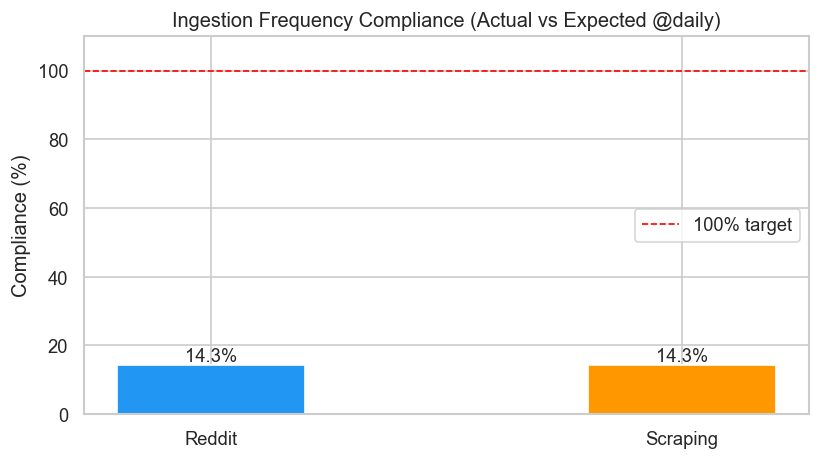

In [38]:
# ── Visual: Ingestion compliance ──────────────────────────────────────────
if not df_gov.empty and 'ingestion_compliance_reddit' in df_gov.columns:
    compliance = {
        'Reddit':   df_gov['ingestion_compliance_reddit'].iloc[0],
        'Scraping': df_gov['ingestion_compliance_scraping'].iloc[0]
    }
    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(compliance.keys(), compliance.values(),
                  color=['#2196F3', '#FF9800'], edgecolor='white', width=0.4)
    ax.set_ylim(0, 110)
    ax.axhline(100, color='red', linestyle='--', linewidth=1, label='100% target')
    ax.set_ylabel('Compliance (%)')
    ax.set_title('Ingestion Frequency Compliance (Actual vs Expected @daily)')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}%', ha='center', fontsize=11)
    ax.legend()
    plt.tight_layout()
    plt.savefig('ingestion_compliance.png', bbox_inches='tight')
    plt.show()

## 6. Storytelling Aggregations Preview

### 6.1 Sentiment Distribution

[SENTIMENT DISTRIBUTION] Loaded: sentiment_distribution_20260529_215406.parquet — 6 rows × 4 cols


,source,sentiment_label,count,pct
0,reddit,negative,25,8.93
1,reddit,neutral,21,7.50
2,reddit,positive,34,12.14
3,scraping,negative,64,22.86
4,scraping,neutral,12,4.29
5,scraping,positive,124,44.29


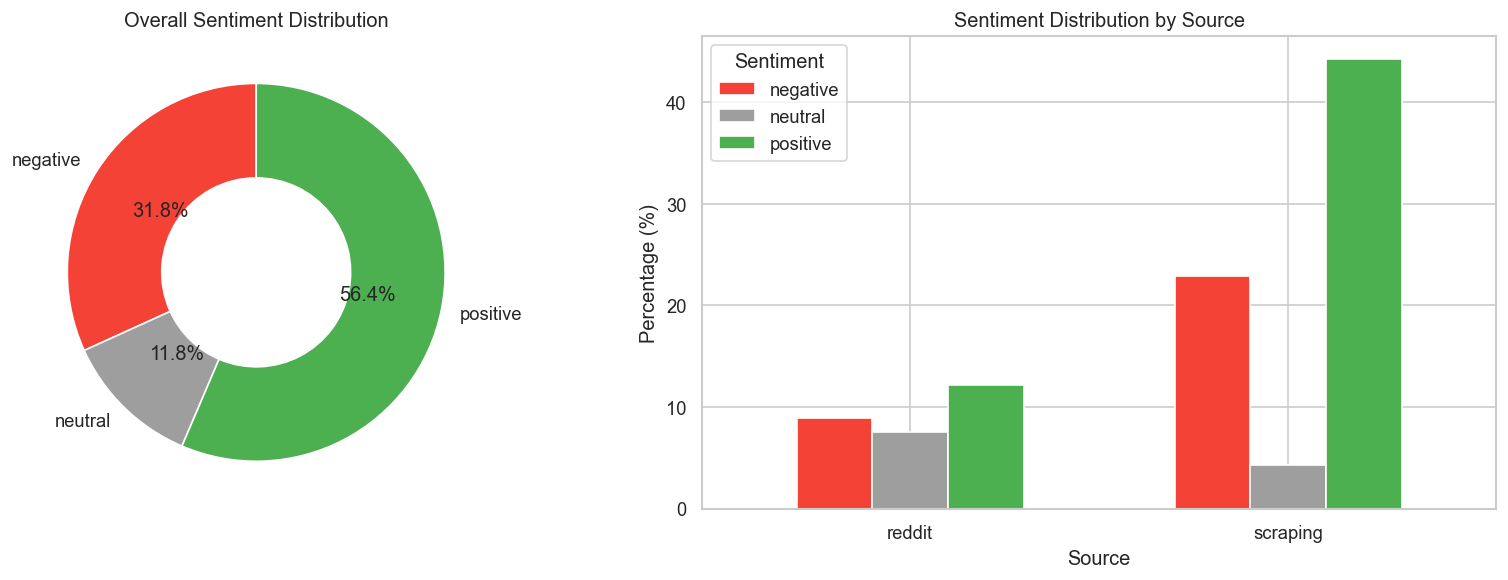

In [39]:
df_sent = load_latest('sentiment_distribution_*.parquet', 'SENTIMENT DISTRIBUTION')
if not df_sent.empty:
    display(df_sent)

    # ── Visual: Donut chart ───────────────────────────────────────────────
    overall = df_sent.groupby('sentiment_label')['count'].sum()
    colors  = {'positive': '#4CAF50', 'neutral': '#9E9E9E', 'negative': '#F44336'}
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Overall donut
    wedge_colors = [colors.get(l, 'blue') for l in overall.index]
    axes[0].pie(overall, labels=overall.index, autopct='%1.1f%%',
                colors=wedge_colors, startangle=90,
                wedgeprops=dict(width=0.5))
    axes[0].set_title('Overall Sentiment Distribution')

    # By source bar chart
    pivot = df_sent.pivot(index='source', columns='sentiment_label', values='pct').fillna(0)
    pivot.plot(kind='bar', ax=axes[1],
               color=[colors.get(c, 'gray') for c in pivot.columns],
               edgecolor='white', width=0.6)
    axes[1].set_title('Sentiment Distribution by Source')
    axes[1].set_xlabel('Source')
    axes[1].set_ylabel('Percentage (%)')
    axes[1].legend(title='Sentiment')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.savefig('sentiment_distribution.png', bbox_inches='tight')
    plt.show()

### 6.2 Sentiment Trend Over Time

NameError: name 'trend_daily' is not defined

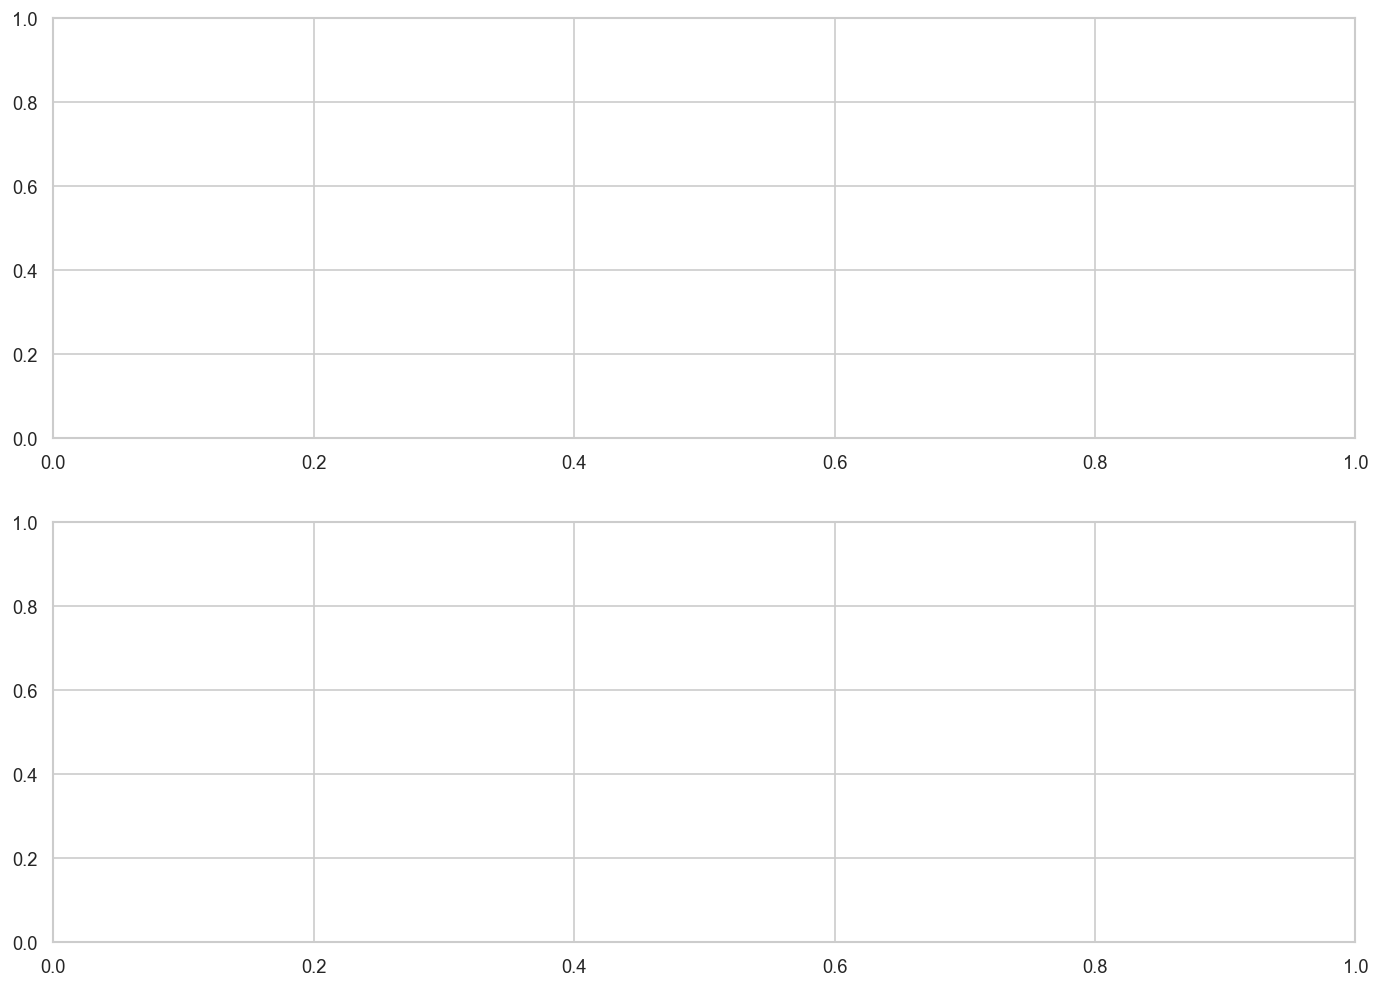

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

colors = {"reddit": "#FF4500", "scraping": "#1E88E5"}

for ax, src in zip(axes, ["scraping", "reddit"]):
    grp = trend_daily[trend_daily["source"] == src].sort_values("date")

    if len(grp) > 1:
        ax.plot(grp["date"], grp["compound_mean"],
                marker="o", color=colors[src], linewidth=2, label=src)
        ax.fill_between(grp["date"], grp["compound_mean"],
                        alpha=0.15, color=colors[src])
    else:
        # Solo un punto — mostrar como scatter con anotación
        ax.scatter(grp["date"], grp["compound_mean"],
                   color=colors[src], s=150, zorder=5, label=src)
        ax.annotate(
            f"Only 1 day of data\nn={grp['n_records'].iloc[0]} posts\ncompound={grp['compound_mean'].iloc[0]:.3f}",
            xy=(grp["date"].iloc[0], grp["compound_mean"].iloc[0]),
            xytext=(0.3, 0.5), textcoords="axes fraction",
            fontsize=10, color="gray",
            arrowprops=dict(arrowstyle="->", color="gray")
        )

    ax.axhline(0,     color="gray",  linestyle="--", linewidth=0.8, alpha=0.7)
    ax.axhline(0.05,  color="green", linestyle=":",  linewidth=0.8, alpha=0.5)
    ax.axhline(-0.05, color="red",   linestyle=":",  linewidth=0.8, alpha=0.5)
    ax.set_title(f"Sentiment Trend — {src.capitalize()} "
                 f"({'insufficient data for trend' if len(grp) <= 1 else f'{len(grp)} days'})")
    ax.set_ylabel("Mean VADER Compound")
    ax.set_ylim(-0.5, 1.1)
    ax.legend()
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Sentiment Trend Over Time — Reddit vs Scraping (Daily)", fontsize=13)
plt.tight_layout()
plt.savefig("sentiment_trend_daily.png", bbox_inches="tight")
plt.show()

print("\n⚠️  Note: Reddit trend requires multiple ingestion cycles.")
print("    Trigger the Bronze DAG daily to accumulate multi-day data.")

### 6.3 Top Keywords

[TOP KEYWORDS] Loaded: top_keywords_20260525_212434.parquet — 30 rows × 2 cols


,keyword,frequency
0,week,444
1,match,436
2,real,169
3,madrid,164
4,run,148
5,good,134
6,game,120
7,player,115
8,goal,115
9,win,107


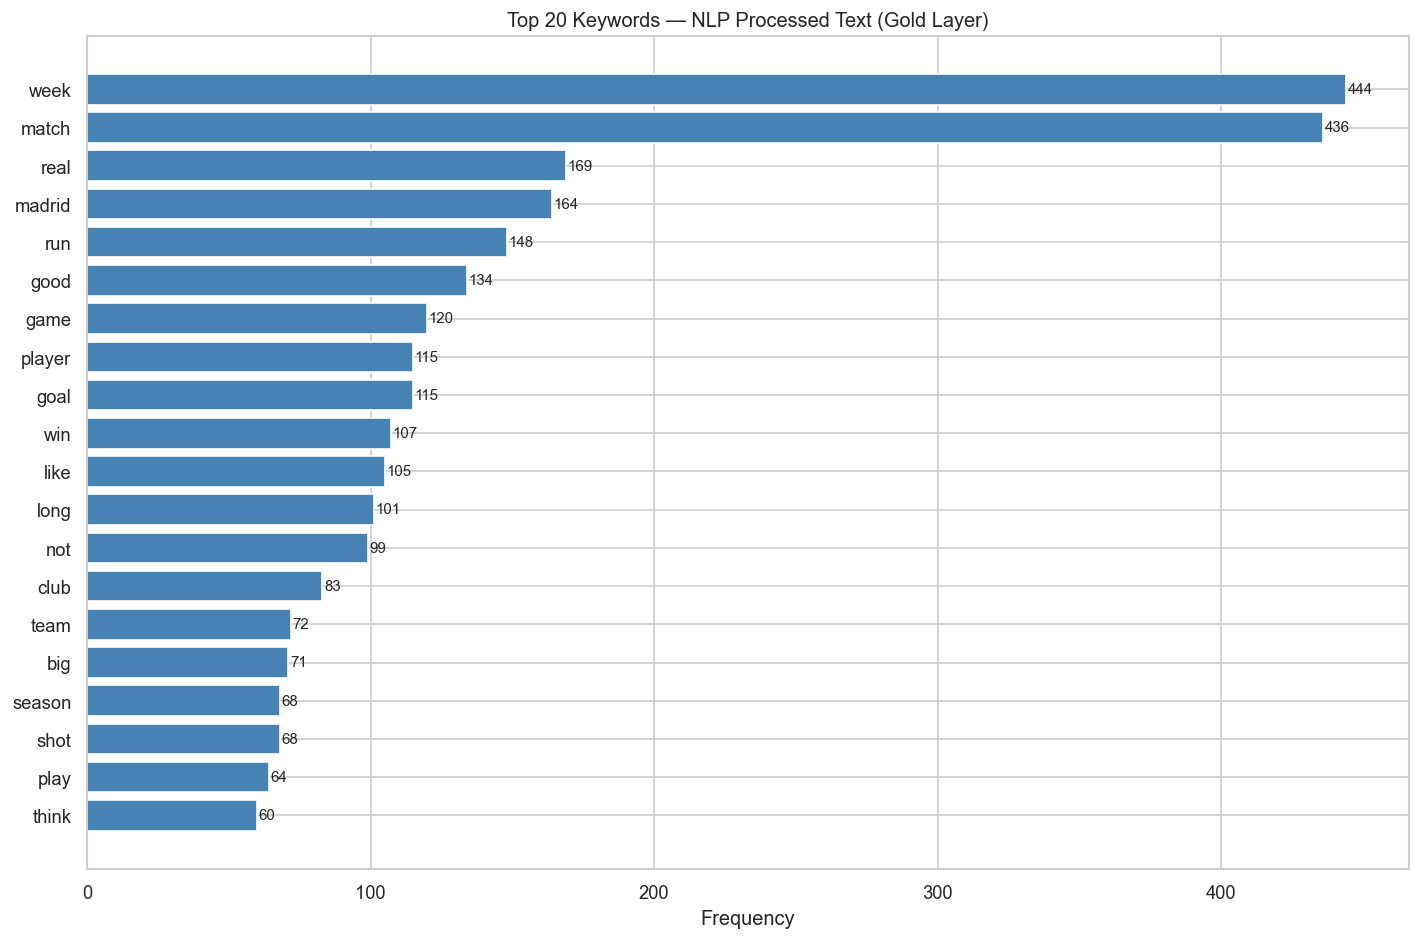

In [ ]:
df_kw = load_latest('top_keywords_*.parquet', 'TOP KEYWORDS')
if not df_kw.empty:
    display(df_kw)

    fig, ax = plt.subplots(figsize=(12, 8))
    top20 = df_kw.nlargest(20, 'frequency')
    ax.barh(top20['keyword'][::-1], top20['frequency'][::-1],
            color='steelblue', edgecolor='white')
    ax.set_xlabel('Frequency')
    ax.set_title('Top 20 Keywords — NLP Processed Text (Gold Layer)')
    for i, (kw, freq) in enumerate(zip(top20['keyword'][::-1], top20['frequency'][::-1])):
        ax.text(freq + 0.5, i, str(freq), va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('top_keywords.png', bbox_inches='tight')
    plt.show()

### 6.4 Keyword Sentiment

[KEYWORD SENTIMENT] Loaded: keyword_sentiment_20260525_212434.parquet — 20 rows × 4 cols


,keyword,n_mentions,compound_mean,sentiment_mode
0,week,17,0.7543,positive
1,match,16,0.9516,positive
2,real,57,0.6405,positive
3,madrid,55,0.6526,positive
4,run,11,0.6900,positive
5,good,15,0.9124,positive
6,game,16,0.8367,positive
7,player,27,0.7399,positive
8,goal,16,0.7725,positive
9,win,20,0.8250,positive


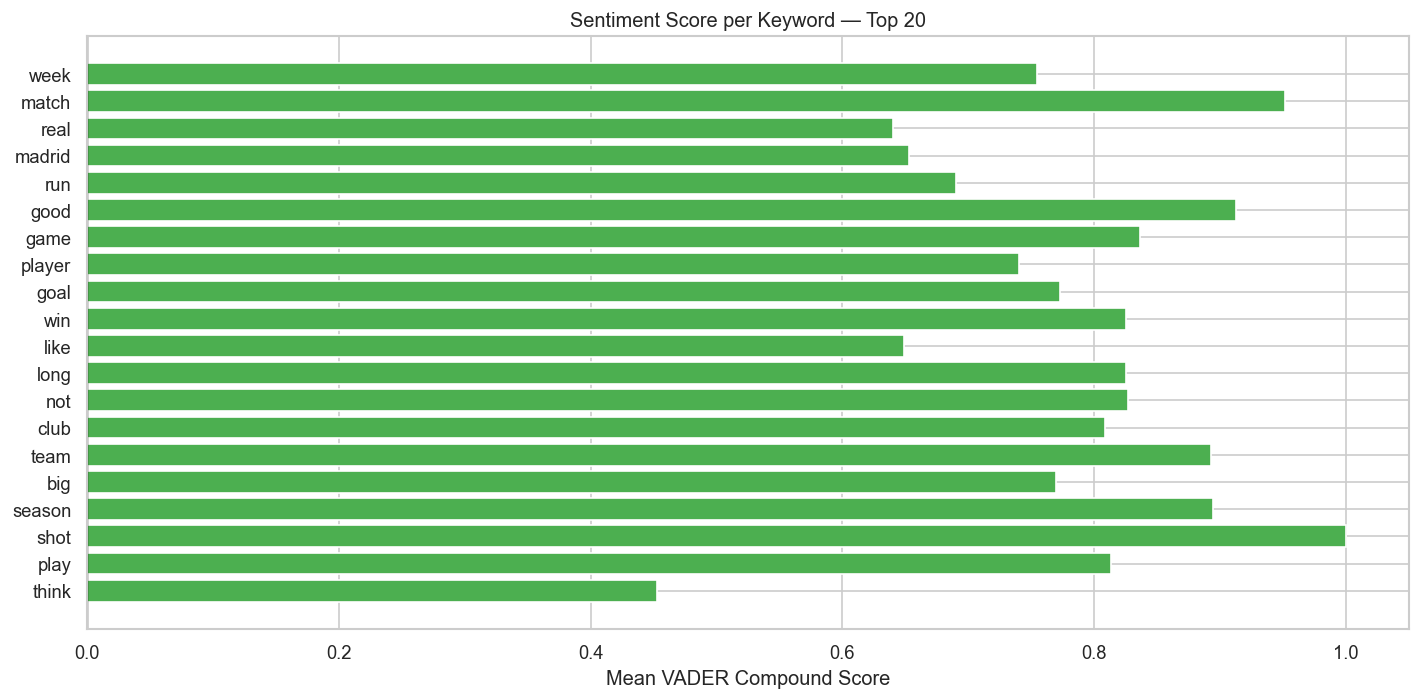

In [ ]:
df_kws = load_latest('keyword_sentiment_*.parquet', 'KEYWORD SENTIMENT')
if not df_kws.empty:
    display(df_kws)

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = df_kws['sentiment_mode'].map(
        {'positive': '#4CAF50', 'neutral': '#9E9E9E', 'negative': '#F44336'}
    )
    bars = ax.barh(df_kws['keyword'][::-1], df_kws['compound_mean'][::-1],
                   color=colors[::-1], edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Mean VADER Compound Score')
    ax.set_title('Sentiment Score per Keyword — Top 20')
    plt.tight_layout()
    plt.savefig('keyword_sentiment.png', bbox_inches='tight')
    plt.show()

### 6.5 Source Comparison

[SOURCE COMPARISON] Loaded: source_comparison_20260525_212434.parquet — 2 rows × 8 cols


,source,n_records,compound_mean,compound_std,pct_positive,pct_neutral,pct_negative,avg_token_count
0,reddit,81,0.1533,0.5548,43.2099,25.9259,30.8642,111.9877
1,scraping,27,0.9003,0.1663,100.0000,0.0000,0.0000,149.7037


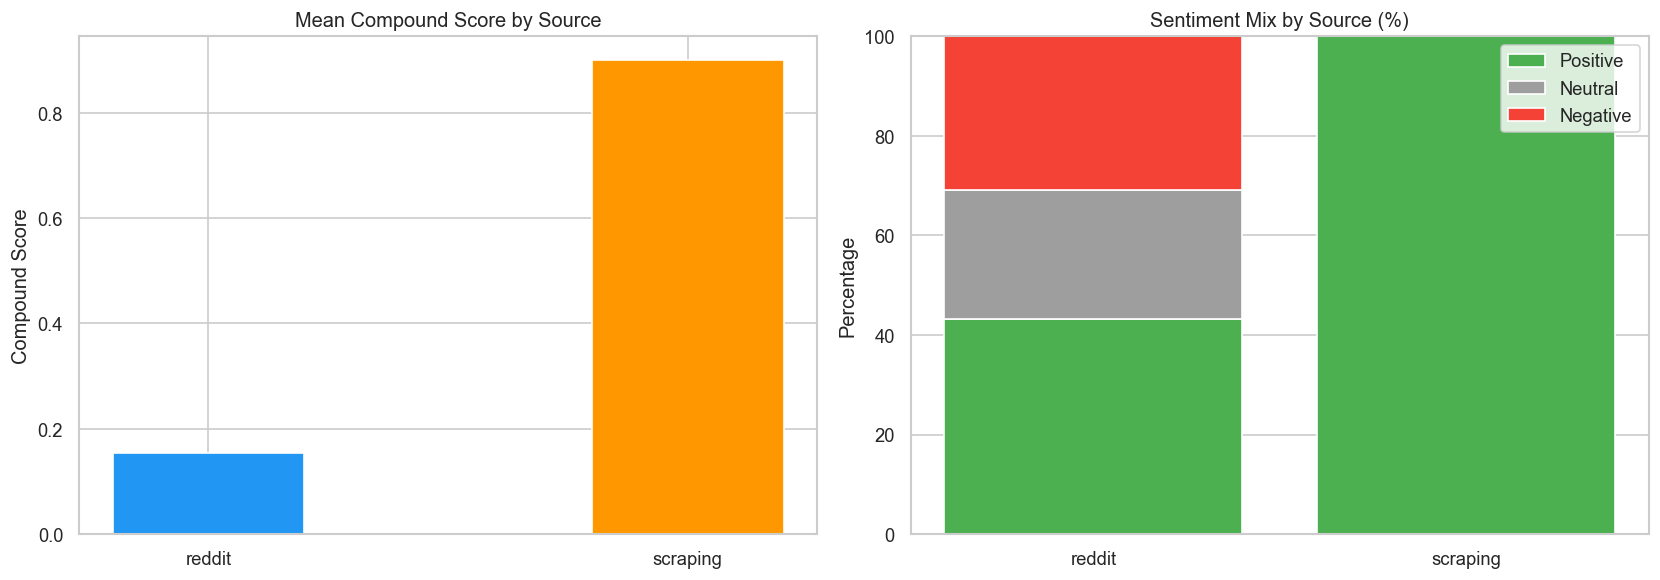

In [ ]:
df_src = load_latest('source_comparison_*.parquet', 'SOURCE COMPARISON')
if not df_src.empty:
    display(df_src)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Compound mean by source
    axes[0].bar(df_src['source'], df_src['compound_mean'],
                color=['#2196F3', '#FF9800'], edgecolor='white', width=0.4)
    axes[0].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[0].set_title('Mean Compound Score by Source')
    axes[0].set_ylabel('Compound Score')

    # Sentiment % stacked by source
    x = range(len(df_src))
    axes[1].bar(df_src['source'], df_src['pct_positive'],  label='Positive',  color='#4CAF50')
    axes[1].bar(df_src['source'], df_src['pct_neutral'],   label='Neutral',   color='#9E9E9E',
                bottom=df_src['pct_positive'])
    axes[1].bar(df_src['source'], df_src['pct_negative'],  label='Negative',  color='#F44336',
                bottom=df_src['pct_positive'] + df_src['pct_neutral'])
    axes[1].set_title('Sentiment Mix by Source (%)')
    axes[1].set_ylabel('Percentage')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('source_comparison.png', bbox_inches='tight')
    plt.show()

### 6.6 Aspect-Based Sentiment

[ASPECT SENTIMENT] Loaded: aspect_sentiment_20260525_212434.parquet — 23 rows × 9 cols


,aspect,source,n_mentions,compound_mean,compound_std,pct_positive,pct_neutral,pct_negative,sentiment_mode
0,mourinho,all,13,0.7888,0.4218,84.62,7.69,7.69,positive
1,mourinho,reddit,4,0.4186,0.6654,50.00,25.00,25.00,positive
2,mourinho,scraping,9,0.9534,0.0423,100.00,0.00,0.00,positive
3,mbappe,all,10,0.8132,0.3159,90.00,0.00,10.00,positive
4,mbappe,reddit,6,0.7098,0.3835,83.33,0.00,16.67,positive
5,mbappe,scraping,4,0.9683,0.0264,100.00,0.00,0.00,positive
6,vinicius,all,3,0.9651,0.0272,100.00,0.00,0.00,positive
7,vinicius,scraping,3,0.9651,0.0272,100.00,0.00,0.00,positive
8,carvajal,all,20,0.7394,0.5076,85.00,5.00,10.00,positive
9,carvajal,reddit,6,0.2980,0.7911,50.00,16.67,33.33,positive


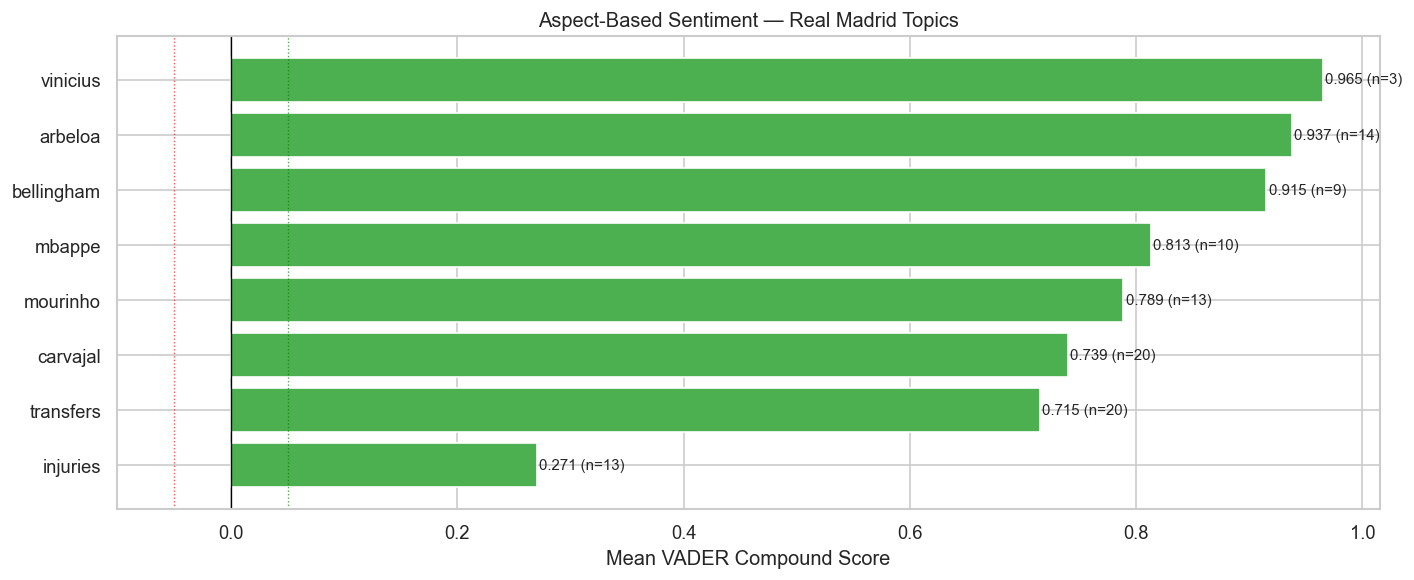

In [ ]:
df_asp = load_latest('aspect_sentiment_*.parquet', 'ASPECT SENTIMENT')
if not df_asp.empty:
    display(df_asp)

    # ── Visual: Compound by aspect (global) ───────────────────────────────
    global_asp = df_asp[df_asp['source'] == 'all'].sort_values('compound_mean')

    if not global_asp.empty:
        fig, ax = plt.subplots(figsize=(12, 5))
        colors = ['#4CAF50' if v >= 0.05 else '#F44336' if v <= -0.05 else '#9E9E9E'
                  for v in global_asp['compound_mean']]
        ax.barh(global_asp['aspect'], global_asp['compound_mean'],
                color=colors, edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.8)
        ax.axvline(0.05,  color='green', linestyle=':', linewidth=0.8, alpha=0.7)
        ax.axvline(-0.05, color='red',   linestyle=':', linewidth=0.8, alpha=0.7)
        ax.set_xlabel('Mean VADER Compound Score')
        ax.set_title('Aspect-Based Sentiment — Real Madrid Topics')

        for i, (_, row) in enumerate(global_asp.iterrows()):
            ax.text(row['compound_mean'] + 0.002, i,
                    f"{row['compound_mean']:.3f} (n={row['n_mentions']})",
                    va='center', fontsize=9)

        plt.tight_layout()
        plt.savefig('aspect_sentiment.png', bbox_inches='tight')
        plt.show()

## 7. Storytelling Summary Metadata

In [ ]:
df_story = load_latest('storytelling_summary_*.parquet', 'STORYTELLING SUMMARY')
if not df_story.empty:
    display(df_story.T.rename(columns={0: 'value'}))

[STORYTELLING SUMMARY] Loaded: storytelling_summary_20260525_212434.parquet — 1 rows × 9 cols


,value
pipeline_run_ts,20260525_212434
total_records,108
sources,"['scraping', 'reddit']"
weeks_covered,2
top_keyword,week
overall_sentiment,positive
overall_compound,0.34
aggregations_saved,"['sentiment_distribution', 'sentiment_trend', ..."
aspects_analyzed,"['mourinho', 'mbappe', 'vinicius', 'carvajal',..."


## 8. Dashboard Narrative

Based on the Gold layer aggregations above, the storytelling dashboard will communicate the following narrative to the functional user:

> **"Real Madrid fan sentiment on Reddit vs sports press coverage — who is more optimistic?"**
>
> The dashboard answers:
> 1. Is public opinion on Real Madrid positive, negative, or neutral — and has that changed over time?
> 2. Which players and topics (transfers, injuries) generate the strongest reactions?
> 3. Do fans on Reddit express sentiment differently from journalists in sports media?
> 4. What are the most discussed topics in Real Madrid coverage, and are they positive or negative?

Each Gold aggregation maps to a specific chart in the Workshop 4 dashboard.

In [ ]:
mapping = [
    {'aggregation': 'sentiment_distribution', 'chart': 'Donut chart + KPI cards', 'user_story': 'US-01: User wants overall sentiment summary'},
    {'aggregation': 'sentiment_trend',        'chart': 'Line chart (compound over time)', 'user_story': 'US-02: User wants temporal opinion shifts'},
    {'aggregation': 'top_keywords',           'chart': 'Bar chart / Word cloud', 'user_story': 'US-03: User wants to know what topics dominate'},
    {'aggregation': 'keyword_sentiment',      'chart': 'Horizontal bar (color=sentiment)', 'user_story': 'US-03: User wants keyword-level sentiment'},
    {'aggregation': 'source_comparison',      'chart': 'Side-by-side bar + stacked bar', 'user_story': 'US-04: User wants Reddit vs press comparison'},
    {'aggregation': 'volume_trend',           'chart': 'Area chart', 'user_story': 'US-05: User wants activity peak detection'},
    {'aggregation': 'aspect_sentiment',       'chart': 'Horizontal bar by player/topic', 'user_story': 'US-06: User wants player-level sentiment'},
]

display(pd.DataFrame(mapping))

,aggregation,chart,user_story
0,sentiment_distribution,Donut chart + KPI cards,US-01: User wants overall sentiment summary
1,sentiment_trend,Line chart (compound over time),US-02: User wants temporal opinion shifts
2,top_keywords,Bar chart / Word cloud,US-03: User wants to know what topics dominate
3,keyword_sentiment,Horizontal bar (color=sentiment),US-03: User wants keyword-level sentiment
4,source_comparison,Side-by-side bar + stacked bar,US-04: User wants Reddit vs press comparison
5,volume_trend,Area chart,US-05: User wants activity peak detection
6,aspect_sentiment,Horizontal bar by player/topic,US-06: User wants player-level sentiment
